## Imports and Setup

In [1]:
import os
import random
import warnings
import numpy as np
import polars as pl
import scipy
import scipy.stats as stats
import sklearn
import joblib
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, r2_score

import plotly.io as pio

pio.renderers.default = "png"
pio.defaults.default_scale = 2

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"numpy       {np.__version__}")
print(f"polars      {pl.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"plotly      {plotly.__version__}")

numpy       2.5.2
polars      1.43.2
scipy       1.18.0
scikit-learn 1.9.0
plotly      6.9.0


## Loading Saved Models, Predictions, and Processed Data

In [2]:
PROCESSED_DATA_DIR = "../data/processed"
MODEL_DIR = "../src_models"

ridge_model = joblib.load(f"{MODEL_DIR}/ridge_best_model.joblib")
lasso_model = joblib.load(f"{MODEL_DIR}/lasso_best_model.joblib")

X_train = pl.read_parquet(f"{PROCESSED_DATA_DIR}/X_train_encoded.parquet")
X_test = pl.read_parquet(f"{PROCESSED_DATA_DIR}/X_test_encoded.parquet")
y_train = pl.read_parquet(f"{PROCESSED_DATA_DIR}/y_train.parquet")
y_test = pl.read_parquet(f"{PROCESSED_DATA_DIR}/y_test.parquet")

predictions = pl.read_parquet(f"{PROCESSED_DATA_DIR}/notebook3_test_predictions.parquet")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"predictions: {predictions.shape}")
predictions.head()

X_train: (137, 71), X_test: (68, 71)
y_train: (137, 2), y_test: (68, 2)
predictions: (68, 4)


y_test_price,pred_test_ols_log_dollar,pred_test_ridge_dollar,pred_test_lasso_dollar
f64,f64,f64,f64
30760.0,30268.224279,28033.834908,29538.841557
17859.167,24230.405425,20692.863412,20343.872978
9549.0,9208.740443,8650.449279,9053.061889
11850.0,12722.843191,13981.017697,13522.748969
28248.0,26452.76105,26539.078317,27961.84435


## Refitting OLS for Train-Set Metrics since only test predictions were saved

In [3]:
y_train_log = y_train["price_log"].to_numpy()
y_test_log = y_test["price_log"].to_numpy()
y_train_price = y_train["price"].to_numpy()
y_test_price = y_test["price"].to_numpy()

ols_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
ols_pipeline.fit(X_train, y_train_log)

pred_train_ols_log = ols_pipeline.predict(X_train)
pred_train_ols_dollar = np.exp(pred_train_ols_log)

print(f"OLS refit complete")
print(f"Train RMSE (dollar): {root_mean_squared_error(y_train_price, pred_train_ols_dollar):.2f}")
print(f"Train R2: {r2_score(y_train_price, pred_train_ols_dollar):.4f}")

OLS refit complete
Train RMSE (dollar): 1167.24
Train R2: 0.9782


## Generating Train-Set Predictions for Ridge and Lasso

In [4]:
pred_train_ridge_log = ridge_model.predict(X_train)
pred_train_ridge_dollar = np.exp(pred_train_ridge_log)

pred_train_lasso_log = lasso_model.predict(X_train)
pred_train_lasso_dollar = np.exp(pred_train_lasso_log)

print(f"Ridge train RMSE (dollar): {root_mean_squared_error(y_train_price, pred_train_ridge_dollar):.2f}")
print(f"Lasso train RMSE (dollar): {root_mean_squared_error(y_train_price, pred_train_lasso_dollar):.2f}")

Ridge train RMSE (dollar): 1277.65
Lasso train RMSE (dollar): 1438.61


## Full Model Comparison Table

In [5]:
comparison = pl.DataFrame({
    "model": ["OLS", "OLS", "Ridge", "Ridge", "Lasso", "Lasso"],
    "set": ["train", "test", "train", "test", "train", "test"],
    "rmse_dollar": [
        root_mean_squared_error(y_train_price, pred_train_ols_dollar),
        root_mean_squared_error(y_test_price, predictions["pred_test_ols_log_dollar"]),
        root_mean_squared_error(y_train_price, pred_train_ridge_dollar),
        root_mean_squared_error(y_test_price, predictions["pred_test_ridge_dollar"]),
        root_mean_squared_error(y_train_price, pred_train_lasso_dollar),
        root_mean_squared_error(y_test_price, predictions["pred_test_lasso_dollar"]),
    ],
    "rmse_log": [
        root_mean_squared_error(y_train_log, pred_train_ols_log),
        root_mean_squared_error(y_test_log, np.log(predictions["pred_test_ols_log_dollar"])),
        root_mean_squared_error(y_train_log, pred_train_ridge_log),
        root_mean_squared_error(y_test_log, np.log(predictions["pred_test_ridge_dollar"])),
        root_mean_squared_error(y_train_log, pred_train_lasso_log),
        root_mean_squared_error(y_test_log, np.log(predictions["pred_test_lasso_dollar"])),
    ],
    "r2": [
        r2_score(y_train_price, pred_train_ols_dollar),
        r2_score(y_test_price, predictions["pred_test_ols_log_dollar"]),
        r2_score(y_train_price, pred_train_ridge_dollar),
        r2_score(y_test_price, predictions["pred_test_ridge_dollar"]),
        r2_score(y_train_price, pred_train_lasso_dollar),
        r2_score(y_test_price, predictions["pred_test_lasso_dollar"]),
    ],
})

comparison

model,set,rmse_dollar,rmse_log,r2
str,str,f64,f64,f64
"""OLS""","""train""",1167.244029,0.083231,0.978185
"""OLS""","""test""",2048.685447,0.163843,0.935859
"""Ridge""","""train""",1277.650473,0.097795,0.973863
"""Ridge""","""test""",2221.28155,0.143424,0.924596
"""Lasso""","""train""",1438.613125,0.099327,0.966863
"""Lasso""","""test""",1979.342328,0.141893,0.940127


## Regularization Paths: Ridge and Lasso Coefficient Trajectories

In [6]:
ridge_alphas = np.logspace(-3, 3, 50)
lasso_alphas = np.logspace(-4, 1, 50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

ridge_coef_path = []
for alpha in ridge_alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train_log)
    ridge_coef_path.append(model.coef_)
ridge_coef_path = np.array(ridge_coef_path)

lasso_coef_path = []
for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train_log)
    lasso_coef_path.append(model.coef_)
lasso_coef_path = np.array(lasso_coef_path)

print(f"ridge_coef_path shape: {ridge_coef_path.shape}")
print(f"lasso_coef_path shape: {lasso_coef_path.shape}")

ridge_coef_path shape: (50, 71)
lasso_coef_path shape: (50, 71)


## Visualizing Regularization Paths

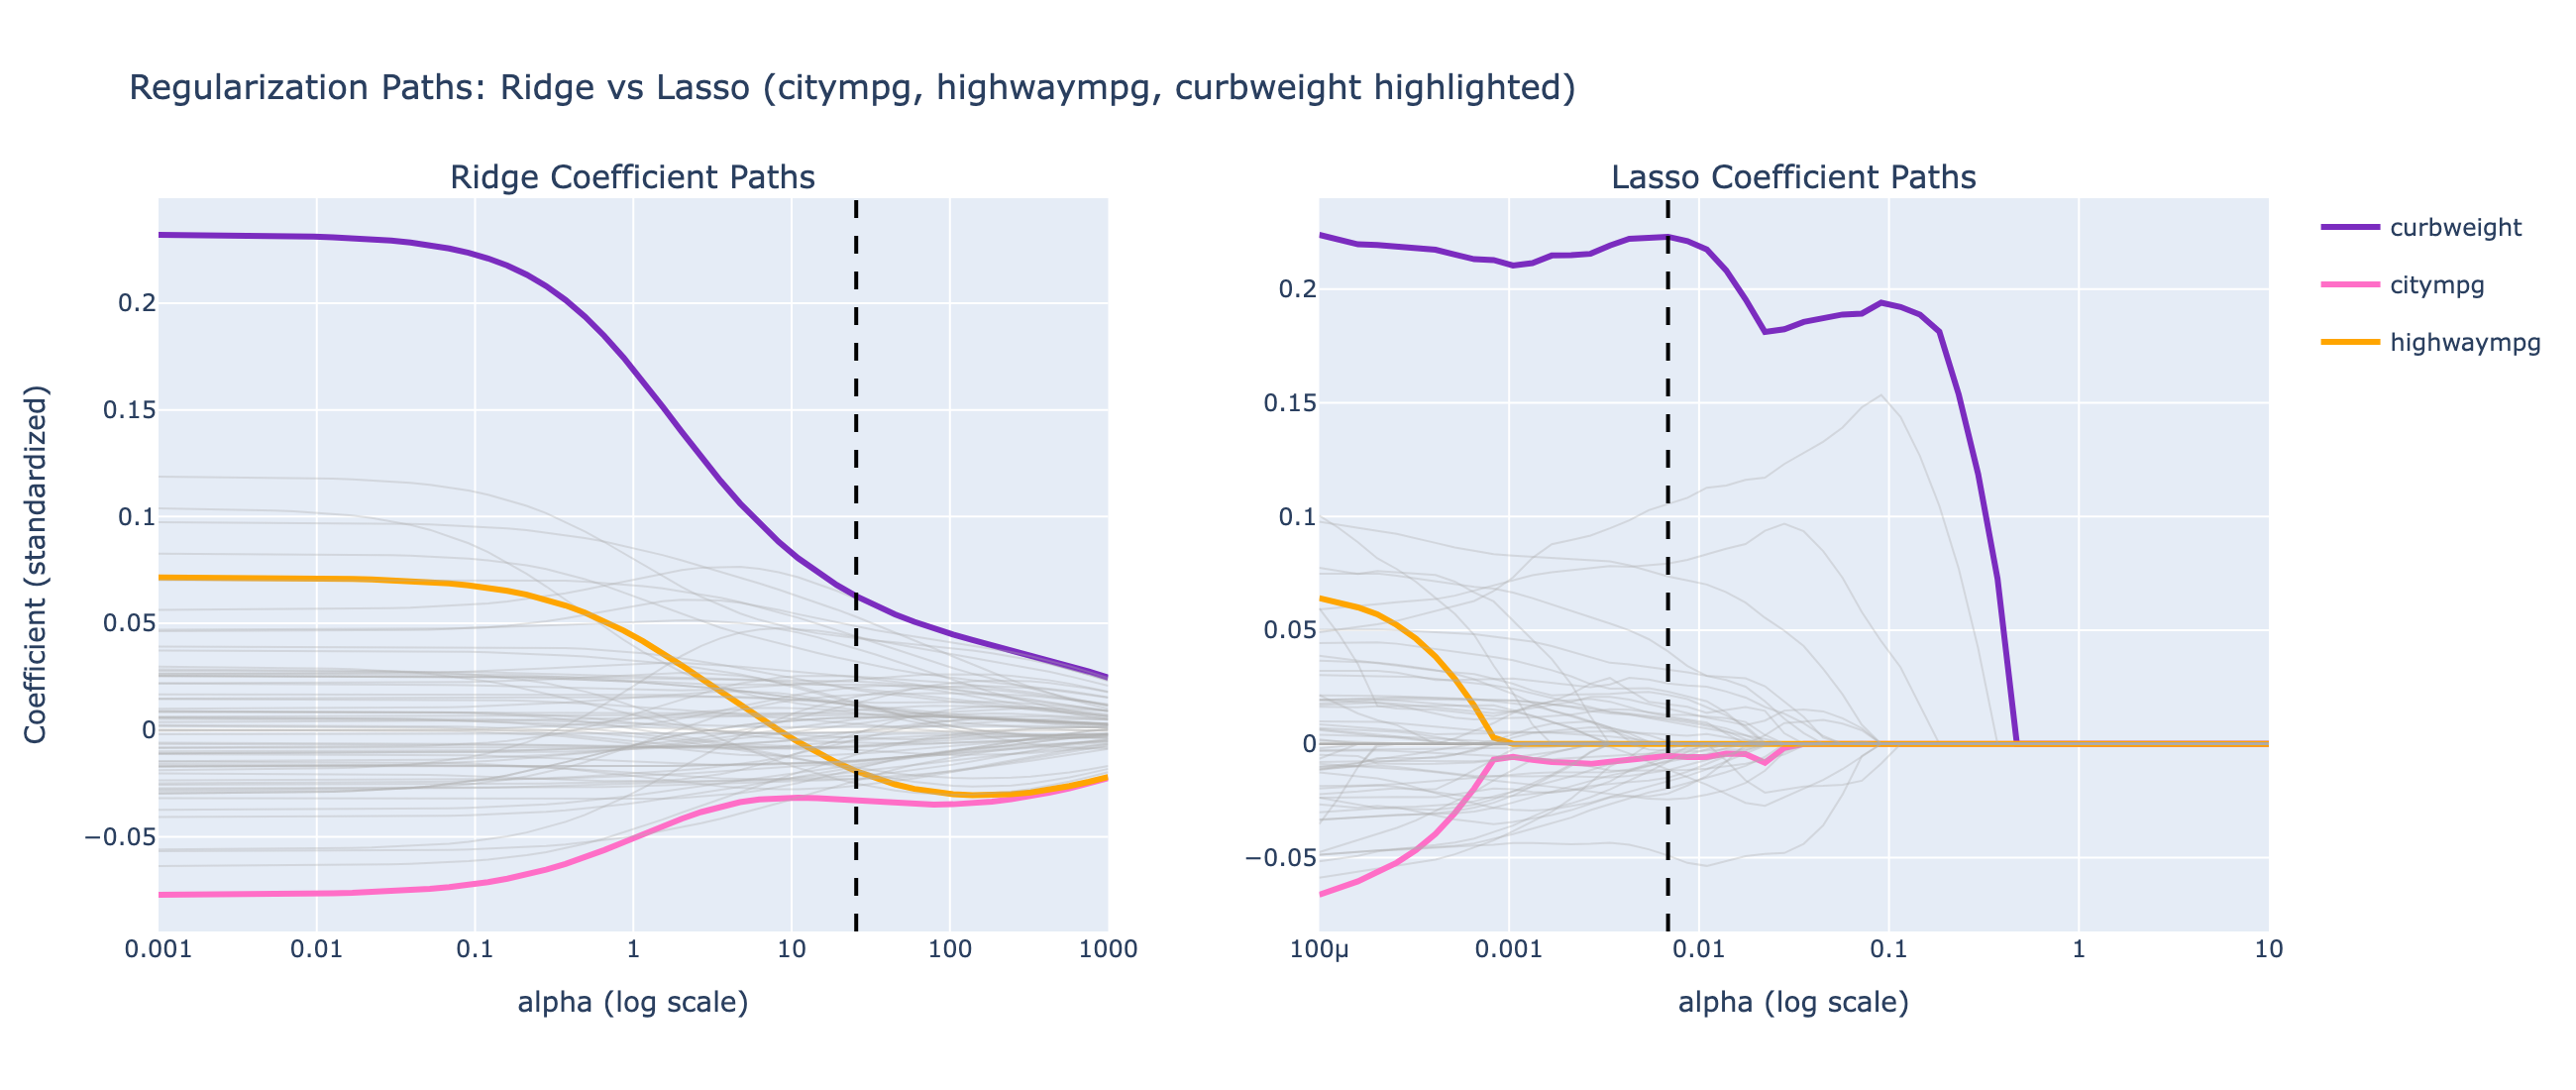

In [8]:
feature_names = X_train.columns
case_study_colors = {
    "curbweight": "#7B2CBF",
    "citympg": "#FF6EC7",
    "highwaympg": "#FFA500",
}

fig = make_subplots(rows=1, cols=2, subplot_titles=["Ridge Coefficient Paths", "Lasso Coefficient Paths"])

for i, name in enumerate(feature_names):
    is_case_study = name in case_study_colors
    fig.add_trace(
        go.Scatter(
            x=ridge_alphas, y=ridge_coef_path[:, i],
            mode="lines",
            line=dict(
                width=3 if is_case_study else 1,
                color=case_study_colors.get(name, "#B0B0B0")
            ),
            name=name,
            legendgroup=name,
            showlegend=is_case_study,
            opacity=1.0 if is_case_study else 0.35
        ),
        row=1, col=1
    )

for i, name in enumerate(feature_names):
    is_case_study = name in case_study_colors
    fig.add_trace(
        go.Scatter(
            x=lasso_alphas, y=lasso_coef_path[:, i],
            mode="lines",
            line=dict(
                width=3 if is_case_study else 1,
                color=case_study_colors.get(name, "#B0B0B0")
            ),
            name=name,
            legendgroup=name,
            showlegend=False,
            opacity=1.0 if is_case_study else 0.35
        ),
        row=1, col=2
    )

fig.add_vline(x=25.5955, line_dash="dash", line_color="black", row=1, col=1)
fig.add_vline(x=0.006866, line_dash="dash", line_color="black", row=1, col=2)

fig.update_xaxes(title_text="alpha (log scale)", type="log", row=1, col=1)
fig.update_xaxes(title_text="alpha (log scale)", type="log", row=1, col=2)
fig.update_yaxes(title_text="Coefficient (standardized)", col=1)

fig.update_layout(
    title="Regularization Paths: Ridge vs Lasso (citympg, highwaympg, curbweight highlighted)",
    height=550,
    width=1300
)

fig.write_image("../reports/figures/16_regularization_paths.png")
fig.show()

## Residual Diagnostics: OLS, Ridge, Lasso

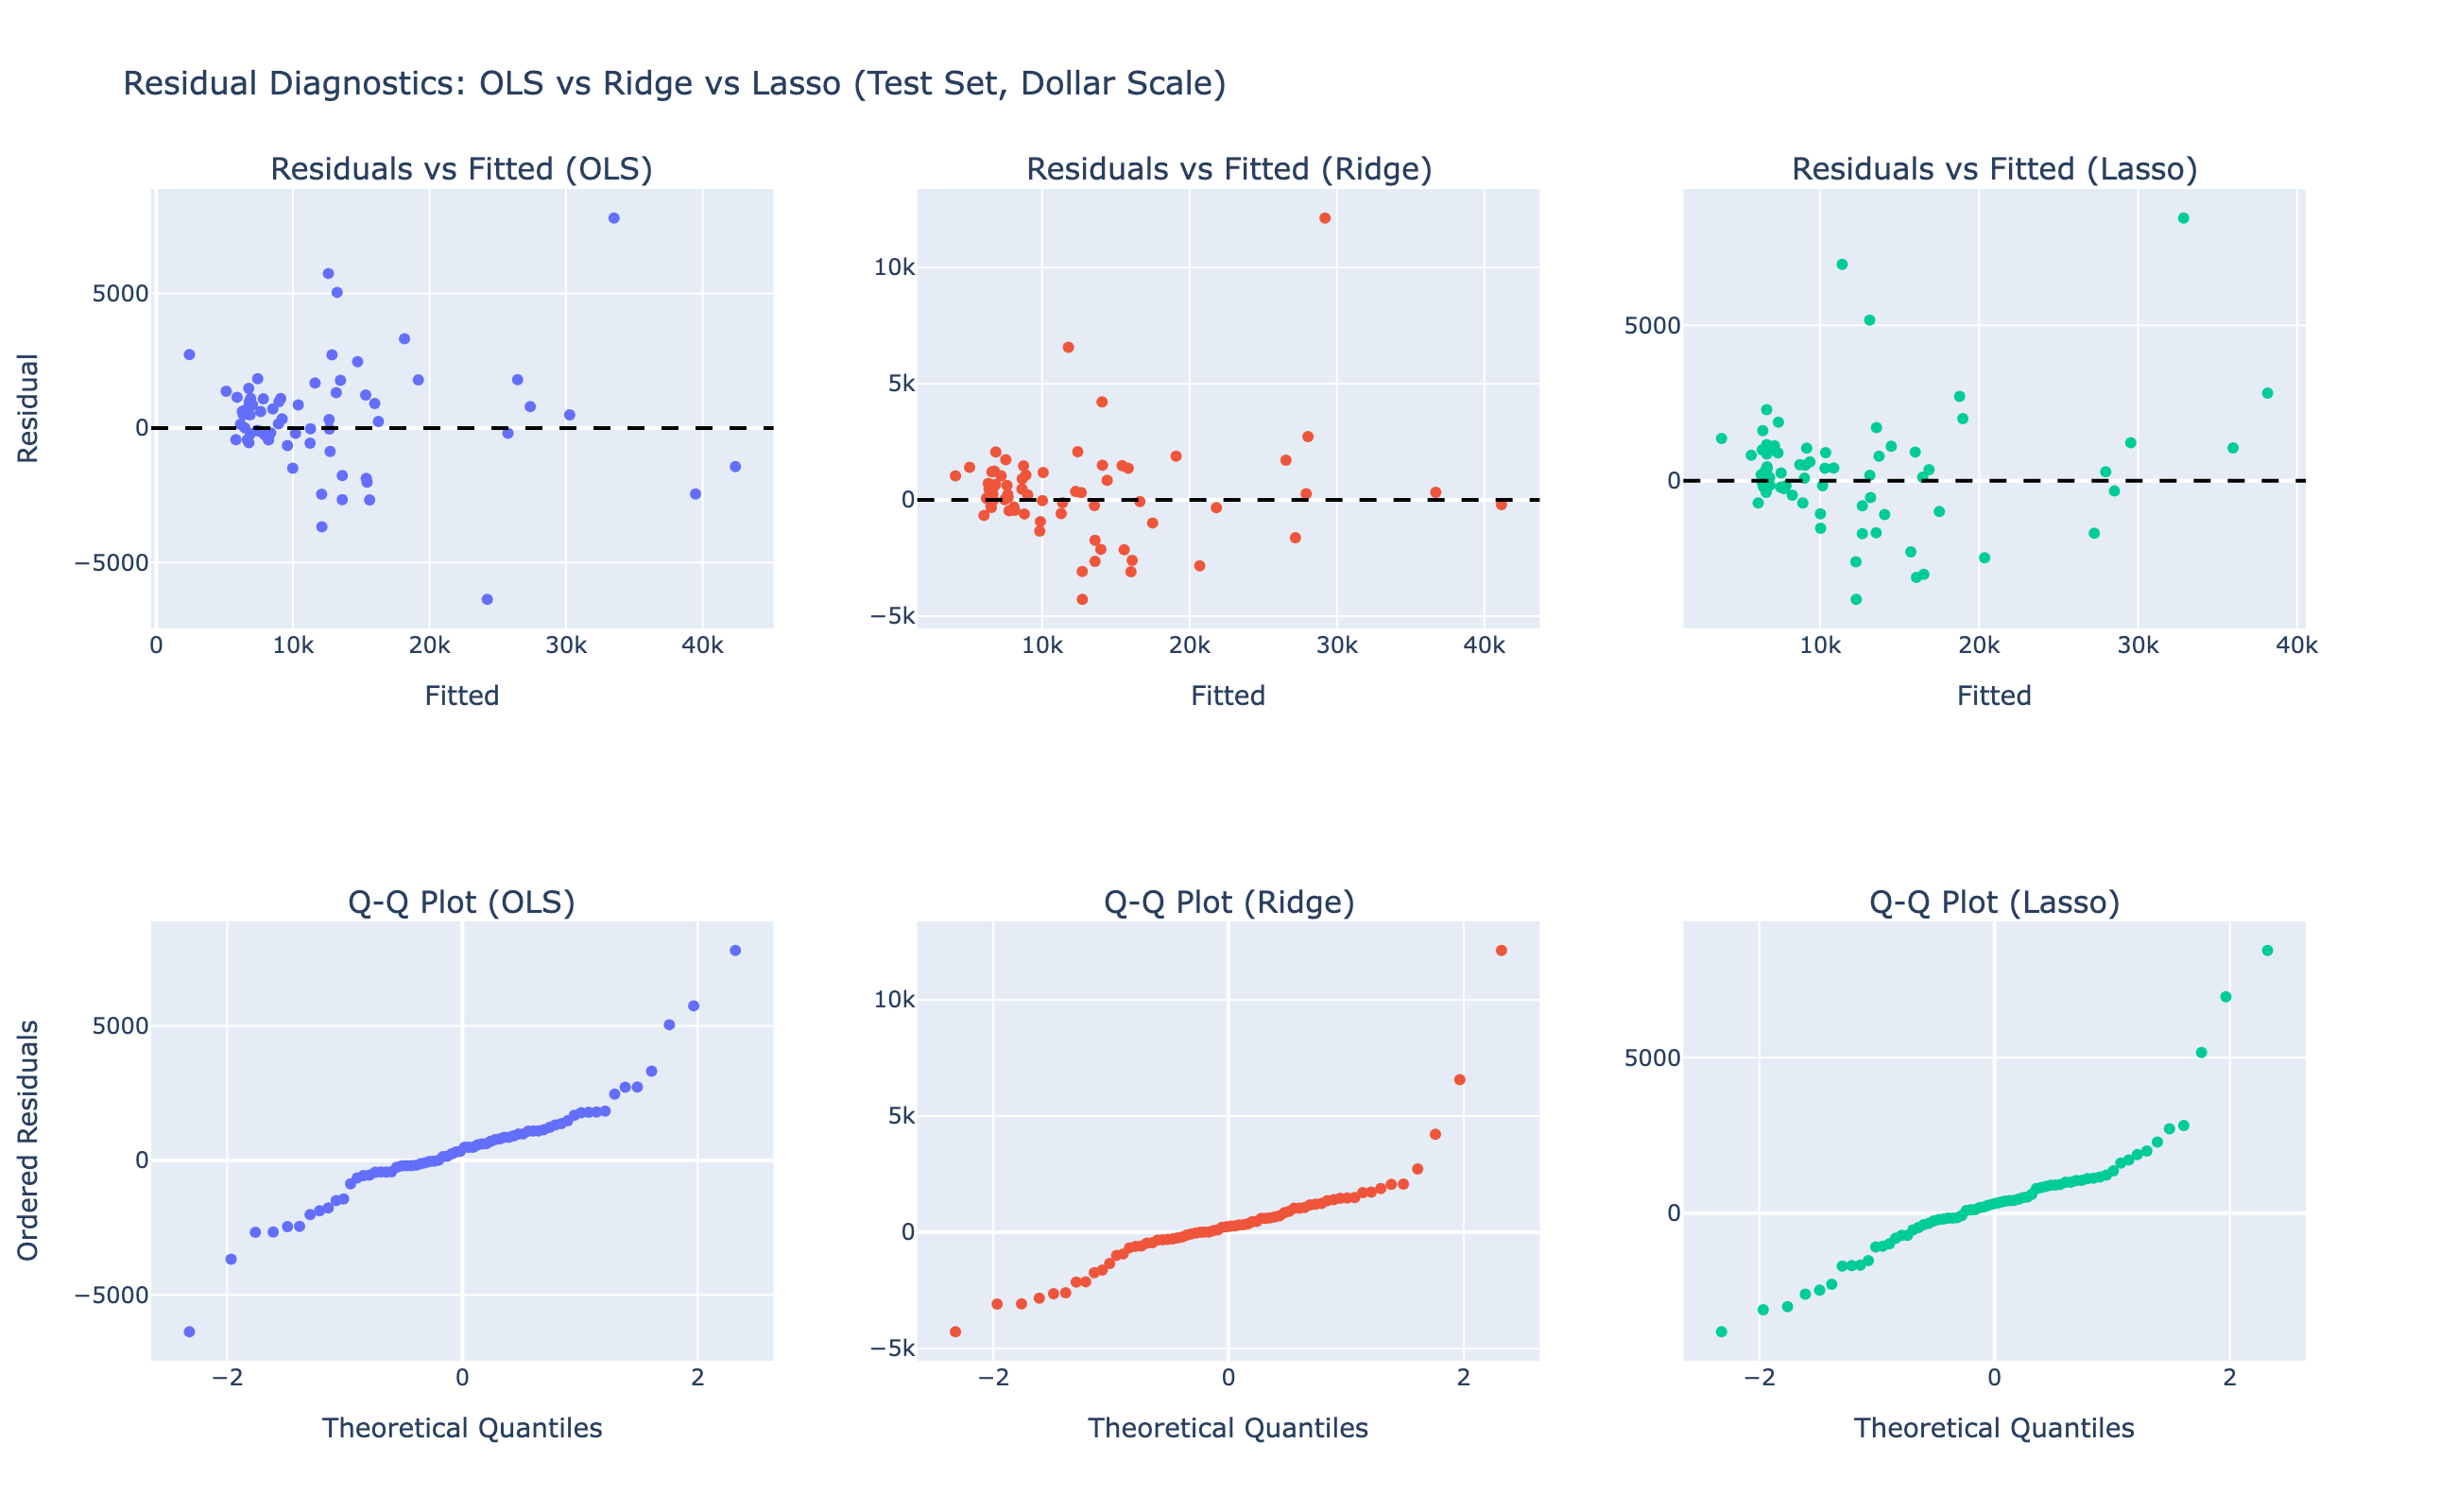

In [9]:
residuals_ols = y_test_price - predictions["pred_test_ols_log_dollar"].to_numpy()
residuals_ridge = y_test_price - predictions["pred_test_ridge_dollar"].to_numpy()
residuals_lasso = y_test_price - predictions["pred_test_lasso_dollar"].to_numpy()

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        "Residuals vs Fitted (OLS)", "Residuals vs Fitted (Ridge)", "Residuals vs Fitted (Lasso)",
        "Q-Q Plot (OLS)", "Q-Q Plot (Ridge)", "Q-Q Plot (Lasso)"
    ]
)

fitted_vals = [
    predictions["pred_test_ols_log_dollar"].to_numpy(),
    predictions["pred_test_ridge_dollar"].to_numpy(),
    predictions["pred_test_lasso_dollar"].to_numpy(),
]
residual_sets = [residuals_ols, residuals_ridge, residuals_lasso]
colors = ["#636EFA", "#EF553B", "#00CC96"]

for i, (fitted, resid, color) in enumerate(zip(fitted_vals, residual_sets, colors)):
    fig.add_trace(
        go.Scatter(x=fitted, y=resid, mode="markers", marker_color=color, showlegend=False),
        row=1, col=i + 1
    )
    fig.add_hline(y=0, line_dash="dash", line_color="black", row=1, col=i + 1)

    qq = stats.probplot(resid, dist="norm")
    fig.add_trace(
        go.Scatter(x=qq[0][0], y=qq[0][1], mode="markers", marker_color=color, showlegend=False),
        row=2, col=i + 1
    )

fig.update_xaxes(title_text="Fitted", row=1)
fig.update_yaxes(title_text="Residual", col=1, row=1)
fig.update_xaxes(title_text="Theoretical Quantiles", row=2)
fig.update_yaxes(title_text="Ordered Residuals", col=1, row=2)

fig.update_layout(
    title="Residual Diagnostics: OLS vs Ridge vs Lasso (Test Set, Dollar Scale)",
    height=800,
    width=1300
)

fig.write_image("../reports/figures/17_residual_diagnostics_comparison.png")
fig.show()

## Adjusted R Squared Comparison

In [10]:
n_test = len(y_test_price)

lasso_coefs = lasso_model.named_steps["regressor"].coef_
n_features_lasso = int(np.sum(lasso_coefs != 0))
n_features_full = X_train.shape[1]

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_r2_table = pl.DataFrame({
    "model": ["OLS", "Ridge", "Lasso"],
    "n_features": [n_features_full, n_features_full, n_features_lasso],
    "test_r2": [
        r2_score(y_test_price, predictions["pred_test_ols_log_dollar"]),
        r2_score(y_test_price, predictions["pred_test_ridge_dollar"]),
        r2_score(y_test_price, predictions["pred_test_lasso_dollar"]),
    ],
})

adj_r2_table = adj_r2_table.with_columns(
    pl.struct(["test_r2", "n_features"]).map_elements(
        lambda s: adjusted_r2(s["test_r2"], n_test, s["n_features"]), return_dtype=pl.Float64
    ).alias("adjusted_r2")
)

adj_r2_table

model,n_features,test_r2,adjusted_r2
str,i64,f64,f64
"""OLS""",71,0.935859,2.07437
"""Ridge""",71,0.924596,2.263021
"""Lasso""",37,0.940127,0.866284


## Adjusted R Squared Comparison (Train Set)

In [11]:
n_train = len(y_train_price)

adj_r2_train_table = pl.DataFrame({
    "model": ["OLS", "Ridge", "Lasso"],
    "n_features": [n_features_full, n_features_full, n_features_lasso],
    "train_r2": [
        r2_score(y_train_price, pred_train_ols_dollar),
        r2_score(y_train_price, pred_train_ridge_dollar),
        r2_score(y_train_price, pred_train_lasso_dollar),
    ],
})

adj_r2_train_table = adj_r2_train_table.with_columns(
    pl.struct(["train_r2", "n_features"]).map_elements(
        lambda s: adjusted_r2(s["train_r2"], n_train, s["n_features"]), return_dtype=pl.Float64
    ).alias("adjusted_r2")
)

adj_r2_train_table

model,n_features,train_r2,adjusted_r2
str,i64,f64,f64
"""OLS""",71,0.978185,0.954356
"""Ridge""",71,0.973863,0.945313
"""Lasso""",37,0.966863,0.954478


## Consolidated Results Table

In [12]:
final_results = pl.DataFrame({
    "model": ["OLS", "Ridge", "Lasso"],
    "n_features": [n_features_full, n_features_full, n_features_lasso],
    "alpha": [None, 25.5955, 0.006866],
    "train_rmse_dollar": [
        root_mean_squared_error(y_train_price, pred_train_ols_dollar),
        root_mean_squared_error(y_train_price, pred_train_ridge_dollar),
        root_mean_squared_error(y_train_price, pred_train_lasso_dollar),
    ],
    "test_rmse_dollar": [
        root_mean_squared_error(y_test_price, predictions["pred_test_ols_log_dollar"]),
        root_mean_squared_error(y_test_price, predictions["pred_test_ridge_dollar"]),
        root_mean_squared_error(y_test_price, predictions["pred_test_lasso_dollar"]),
    ],
    "train_r2": [
        r2_score(y_train_price, pred_train_ols_dollar),
        r2_score(y_train_price, pred_train_ridge_dollar),
        r2_score(y_train_price, pred_train_lasso_dollar),
    ],
    "test_r2": [
        r2_score(y_test_price, predictions["pred_test_ols_log_dollar"]),
        r2_score(y_test_price, predictions["pred_test_ridge_dollar"]),
        r2_score(y_test_price, predictions["pred_test_lasso_dollar"]),
    ],
    "train_adjusted_r2": adj_r2_train_table["adjusted_r2"].to_list(),
    "train_test_r2_gap": None,
})

final_results = final_results.with_columns(
    (pl.col("train_r2") - pl.col("test_r2")).alias("train_test_r2_gap")
)

final_results = final_results.select(
    "model", "n_features", "alpha",
    "train_rmse_dollar", "test_rmse_dollar",
    "train_r2", "test_r2", "train_adjusted_r2", "train_test_r2_gap"
)

final_results.write_parquet(f"{PROCESSED_DATA_DIR}/notebook4_final_comparison.parquet")

print("Saved notebook4_final_comparison.parquet")
final_results

Saved notebook4_final_comparison.parquet


model,n_features,alpha,train_rmse_dollar,test_rmse_dollar,train_r2,test_r2,train_adjusted_r2,train_test_r2_gap
str,i64,f64,f64,f64,f64,f64,f64,f64
"""OLS""",71,null,1167.244029,2048.685447,0.978185,0.935859,0.954356,0.042326
"""Ridge""",71,25.5955,1277.650473,2221.28155,0.973863,0.924596,0.945313,0.049267
"""Lasso""",37,0.006866,1438.613125,1979.342328,0.966863,0.940127,0.954478,0.026735
